## Cell 1 — Imports & setup

In [13]:
# Cell 1 — imports
import os
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})


## Cell 2 — Load MovieLens movie metadata

In [14]:
# Cell 2 — load movies
base = "../data/ml-100k"

movies = pd.read_csv(
    os.path.join(base, "u.item"),
    sep="|",
    header=None,
    encoding="latin-1",
    names=[
        "movieId", "title", "release_date", "video_release_date",
        "IMDb_URL"
    ] + [f"genre_{i}" for i in range(19)]
)

movies.head()


,movieId,title,release_date,video_release_date,IMDb_URL,genre_0,genre_1,genre_2,genre_3,genre_4,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Cell 3 — Map genre columns to readable genre names

In [15]:
# Cell 3 — load genre mapping
genre_map = {}
with open(os.path.join(base, "u.genre"), "r") as f:
    for line in f:
        if line.strip():
            name, idx = line.strip().split("|")
            genre_map[int(idx)] = name

genre_map


{0: 'unknown',
 1: 'Action',
 2: 'Adventure',
 3: 'Animation',
 4: "Children's",
 5: 'Comedy',
 6: 'Crime',
 7: 'Documentary',
 8: 'Drama',
 9: 'Fantasy',
 10: 'Film-Noir',
 11: 'Horror',
 12: 'Musical',
 13: 'Mystery',
 14: 'Romance',
 15: 'Sci-Fi',
 16: 'Thriller',
 17: 'War',
 18: 'Western'}

## Cell 4 — Create a readable genre string per movie

In [16]:
# Cell 4 — create genre text
genre_cols = [f"genre_{i}" for i in range(19)]

def extract_genres(row):
    genres = []
    for i, col in enumerate(genre_cols):
        if row[col] == 1:
            genres.append(genre_map[i])
    return " ".join(genres)

movies["genres"] = movies.apply(extract_genres, axis=1)

movies[["movieId", "title", "genres"]].head()


,movieId,title,genres
0,1,Toy Story (1995),Animation Children's Comedy
1,2,GoldenEye (1995),Action Adventure Thriller
2,3,Four Rooms (1995),Thriller
3,4,Get Shorty (1995),Action Comedy Drama
4,5,Copycat (1995),Crime Drama Thriller


## STEP 1 — Create Movie Descriptions (Combined Text)

In [17]:
# Cell 5 — combined text field (enhanced features)
# Extract year from title (if present) and ensure genres exist
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').fillna('')
movies['genres'] = movies['genres'].fillna('')

# Repeat genres to increase their weight and include year in the combined text
# Also replace any pipe separators with spaces if present
movies['combined'] = (
    movies['title'] + ' ' +
    movies['genres'].str.replace('|', ' ') + ' ' +
    movies['genres'] + ' ' +
    movies['year'].astype(str)
)

movies[["title", "year", "genres", "combined"]].head()

,title,year,genres,combined
0,Toy Story (1995),1995,Animation Children's Comedy,Toy Story (1995) Animation Children's Comedy A...
1,GoldenEye (1995),1995,Action Adventure Thriller,GoldenEye (1995) Action Adventure Thriller Act...
2,Four Rooms (1995),1995,Thriller,Four Rooms (1995) Thriller Thriller 1995
3,Get Shorty (1995),1995,Action Comedy Drama,Get Shorty (1995) Action Comedy Drama Action C...
4,Copycat (1995),1995,Crime Drama Thriller,Copycat (1995) Crime Drama Thriller Crime Dram...


## STEP 2 — TF-IDF Vectorization

In [18]:
# Cell 6 — TF-IDF vectorization
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),     # unigrams + bigrams
    min_df=2               # ignore very rare words
)

tfidf_matrix = tfidf.fit_transform(movies["combined"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (1682, 1182)


## STEP 3 — Compute Movie Similarity (Cosine Similarity)

In [19]:
# Cell 7 — cosine similarity matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)


Cosine similarity matrix shape: (1682, 1682)


## STEP 4 — Build Recommendation Function

In [20]:
# Cell 8 — title → index mapping
title_to_index = pd.Series(movies.index, index=movies["title"]).drop_duplicates()


## Recommendation function

In [21]:
# Cell 9 — content-based recommender
def recommend_content(movie_title, top_n=10):
    if movie_title not in title_to_index:
        return f"Movie '{movie_title}' not found."

    idx = title_to_index[movie_title]

    # similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip the first movie (itself)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movies.loc[movie_indices, ["movieId", "title", "genres"]]


## Cell 10 — Test the recommender

In [22]:
recommend_content("Toy Story (1995)")


,movieId,title,genres
1218,1219,"Goofy Movie, A (1995)",Animation Children's Comedy Romance
1065,1066,Balto (1995),Animation Children's
421,422,Aladdin and the King of Thieves (1996),Animation Children's Comedy
1469,1470,Gumby: The Movie (1995),Animation Children's
94,95,Aladdin (1992),Animation Children's Comedy Musical
1411,1412,Land Before Time III: The Time of the Great Gi...,Animation Children's
945,946,"Fox and the Hound, The (1981)",Animation Children's
992,993,Hercules (1997),Adventure Animation Children's Comedy Musical
1408,1409,"Swan Princess, The (1994)",Animation Children's
541,542,Pocahontas (1995),Animation Children's Musical Romance


## Optional — Visualize similarity scores for a movie

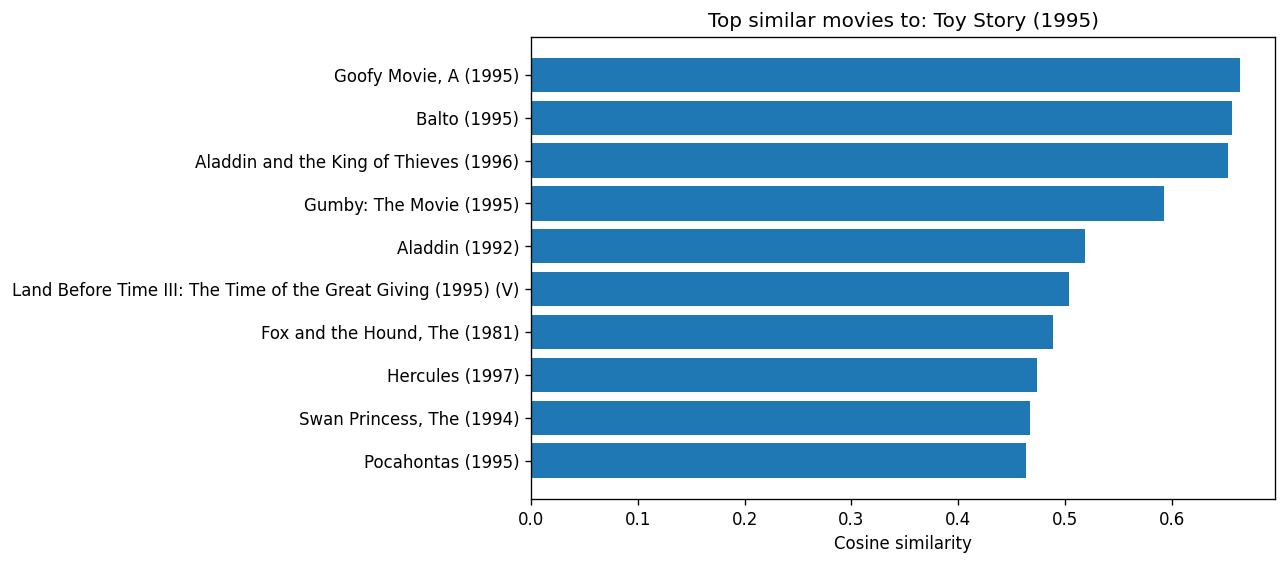

In [23]:
# Cell 11 — similarity visualization (optional)
movie = "Toy Story (1995)"
idx = title_to_index[movie]

scores = sorted(
    list(enumerate(cosine_sim[idx])),
    key=lambda x: x[1],
    reverse=True
)[1:11]

titles = [movies.iloc[i[0]]["title"] for i in scores]
values = [i[1] for i in scores]

plt.barh(titles[::-1], values[::-1])
plt.title(f"Top similar movies to: {movie}")
plt.xlabel("Cosine similarity")
plt.show()


## Optional — Save similarity matrix (usually NOT required)

In [24]:


# Create the full path to the processed directory
processed_dir = os.path.join(os.getcwd(), 'data', 'processed')

# Ensure the directory exists
os.makedirs(processed_dir, exist_ok=True)

# Save the files with full paths
np.save(os.path.join(processed_dir, 'content_cosine_sim.npy'), cosine_sim)
movies.to_csv(os.path.join(processed_dir, 'movies_content.csv'), index=False)
